Import modules, define network and apply transformations

In [3]:
import torch
from torchvision.datasets import Flowers102
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

class FlowersNetwork(nn.Module):
    def __init__(self, in_channels, out_features, activation_function = F.relu):
        super(FlowersNetwork, self).__init__()

        # Block 1
        self.conv1_1 = nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=7, padding=3)
        self.conv1_2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=7, padding=3)  
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2
        self.conv2_1 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.conv2_2 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3
        self.conv3_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv3_3 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Block 4
        self.conv4_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv4_3 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Block 5
        self.conv5_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv5_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_3 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.5)


        self.fc1 = nn.Linear(512, 1024)
        self.fc2 = nn.Linear(1024, out_features)

        self.activation_function = activation_function

    def forward(self, x):
        # Block 1
        x = self.activation_function(self.conv1_1(x))
        x = self.pool(self.activation_function(self.bn1(self.conv1_2(x))))

        # Block 2
        x = self.activation_function(self.conv2_1(x))
        x = self.pool(self.activation_function(self.bn2(self.conv2_2(x))))

        # Block 3
        x = self.activation_function(self.conv3_1(x))
        x = self.activation_function(self.conv3_2(x))
        x = self.pool(self.activation_function(self.bn3(self.conv3_3(x))))

        # Block 4
        x = self.activation_function(self.conv4_1(x))
        x = self.activation_function(self.conv4_2(x))
        x = self.pool(self.activation_function(self.bn4(self.conv4_3(x))))

        # Block 5
        x = self.activation_function(self.conv5_1(x))
        x = self.activation_function(self.conv5_2(x))
        x = self.pool(self.activation_function(self.bn5(self.conv5_3(x))))
        
        # Fully connected layers
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(self.activation_function(self.fc1(x)))
        x = self.fc2(x)
        return x

# Set image dimensions
imageWidth = 224
imageHeight = 224

# Define batch size
batch_size = 32

# Calculate mean and standard deviation of the dataset for normalisation
flowersTransform_no_norm = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.ToTensor()
])

flowersTrain_no_norm = Flowers102(root="./data", split="train", download=True, transform=flowersTransform_no_norm)
train_no_norm_loader = DataLoader(flowersTrain_no_norm, batch_size=batch_size, shuffle=False)

mean = 0.
std = 0.
total_samples = 0

for images, _ in train_no_norm_loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_samples += batch_samples

mean /= total_samples
std /= total_samples

# Apply transformations to dataset
trainingTransform = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

testingTransform = transforms.Compose([
    transforms.Resize((imageWidth, imageHeight)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Combine augmented and original training sets to make 1 large training set
flowersAugmented = Flowers102(root = "./data", split = "train", download=True, transform = trainingTransform)
flowersNormal = Flowers102(root = "./data", split = "train", download=True, transform = testingTransform)
flowersTrain = ConcatDataset([flowersAugmented, flowersNormal])

flowersValidate = Flowers102(root = "./data", split = "val", download=True, transform = testingTransform)
flowersTest = Flowers102(root = "./data", split = "test", download=True, transform = testingTransform)

# Move model onto GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create DataLoaders for batch usage
train_loader = DataLoader(flowersTrain, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(flowersValidate, batch_size=batch_size, shuffle=False)

imageChannels = 3 #R,G,B
imageSize = imageWidth*imageHeight*imageChannels

Initialise classifier, optimiser and loss function. Then train the model, output loss and evaluate accuracy per epoch.

In [4]:
from sklearn.metrics import precision_score, recall_score, f1_score

classifier = FlowersNetwork(in_channels = imageChannels, out_features = 102, activation_function = F.relu)

# Move model to GPU
classifier.to(device)

lossFunction = nn.CrossEntropyLoss()
optimiser = torch.optim.AdamW(classifier.parameters(), lr=0.0001, weight_decay=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.1, patience=5)

epochs = 100
bestLoss = float('inf')
patience = 5
lossTolerance = 1e-4
losses = []
valAccuracies = []
precisions = []
recalls = []
f1Scores = []
for i in range(epochs):
  classifier.train()
  epochLoss = 0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    predictions = classifier.forward(images)

    loss = lossFunction(predictions, labels)
    epochLoss += loss.item()

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

  # Validation phase
  classifier.eval()
  val_loss = 0.0
  correct = 0
  total = 0
  all_labels = []
  all_preds = []
  with torch.no_grad():
      for images, labels in val_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = classifier(images)
          val_loss += lossFunction(outputs, labels).item()
          _, predicted = torch.max(outputs, 1)
          correct += (predicted == labels).sum().item()
          total += labels.size(0)
          all_labels.extend(labels.cpu().numpy())
          all_preds.extend(predicted.cpu().numpy())

  val_loss /= len(val_loader)
  val_accuracy = correct / total
  print(f"Epoch {i + 1}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")
  valAccuracies.append(val_accuracy)

  precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
  recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
  f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
  print(f'Epoch {i + 1} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

  precisions.append(precision)
  recalls.append(recall)
  f1Scores.append(f1)

  scheduler.step(val_loss)

  epochLoss /= len(train_loader)
  losses.append(epochLoss)
  print(f"Epoch {i+1} Training Loss: {epochLoss:.6f}")
  
  # Check for early stopping
  if epochLoss + lossTolerance < bestLoss:
      bestLoss = epochLoss
      patience = 5
  else:
      patience -= 1
      if patience == 0:
          pass
          #print("Loss hasn't improved for the last few epochs. Stopping training.")
          #break

Epoch 1, Validation Loss: 4.3470, Validation Accuracy: 0.0539
Epoch 1 - Precision: 0.0180, Recall: 0.0539, F1 Score: 0.0160
Epoch 1 Training Loss: 4.515123
Epoch 2, Validation Loss: 3.8748, Validation Accuracy: 0.0745
Epoch 2 - Precision: 0.0279, Recall: 0.0745, F1 Score: 0.0257
Epoch 2 Training Loss: 4.158221
Epoch 3, Validation Loss: 3.9792, Validation Accuracy: 0.0784
Epoch 3 - Precision: 0.0315, Recall: 0.0784, F1 Score: 0.0316
Epoch 3 Training Loss: 3.909935
Epoch 4, Validation Loss: 3.6858, Validation Accuracy: 0.1029
Epoch 4 - Precision: 0.0543, Recall: 0.1029, F1 Score: 0.0549
Epoch 4 Training Loss: 3.782261
Epoch 5, Validation Loss: 3.6160, Validation Accuracy: 0.1078
Epoch 5 - Precision: 0.0712, Recall: 0.1078, F1 Score: 0.0506
Epoch 5 Training Loss: 3.641442
Epoch 6, Validation Loss: 3.3952, Validation Accuracy: 0.1578
Epoch 6 - Precision: 0.1253, Recall: 0.1578, F1 Score: 0.1112
Epoch 6 Training Loss: 3.508873
Epoch 7, Validation Loss: 3.3920, Validation Accuracy: 0.1441
Ep

Plot graphs

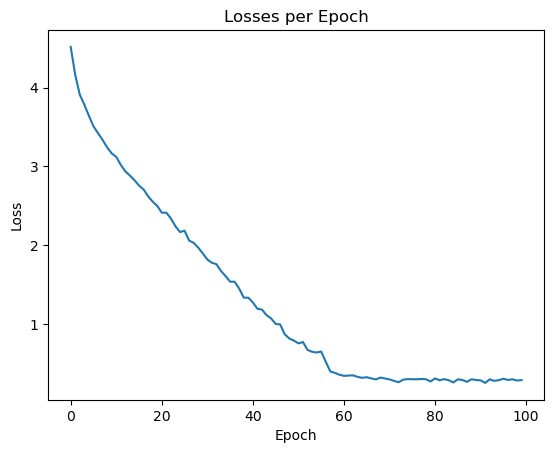

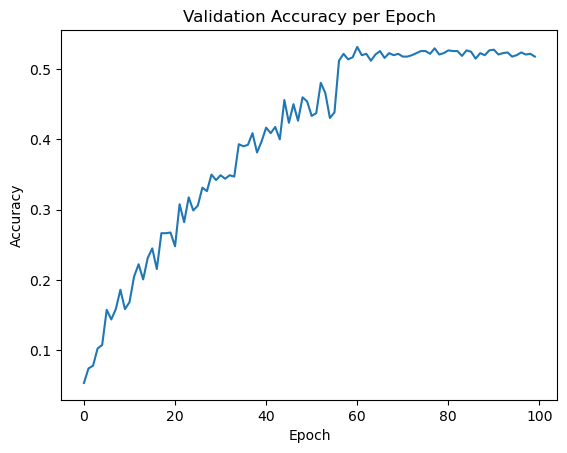

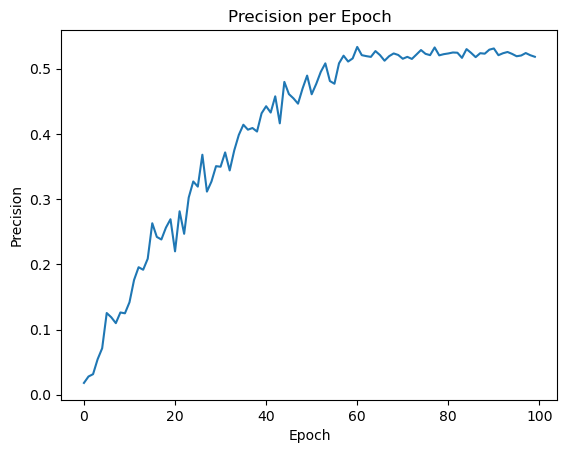

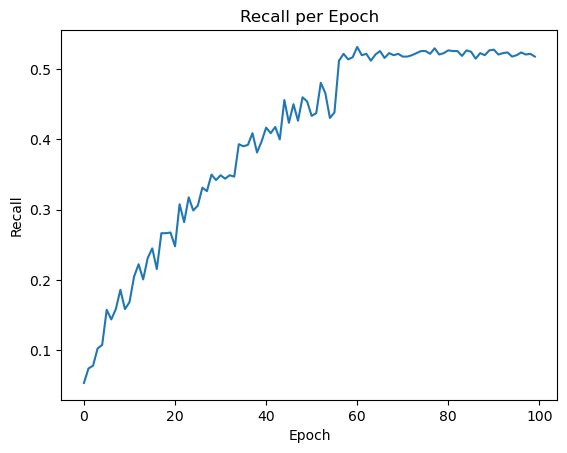

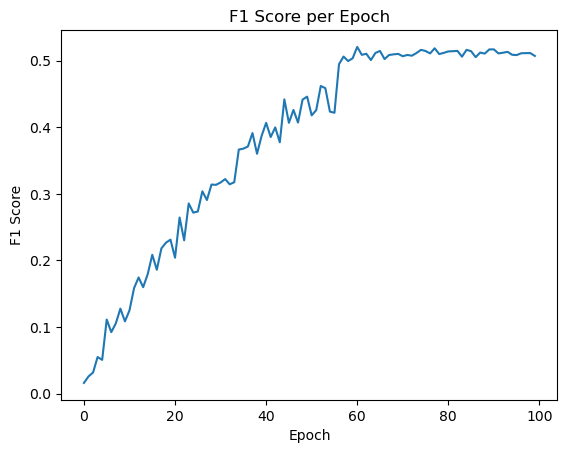

In [5]:
plt.plot(range(len(losses)), losses)
plt.title("Losses per Epoch")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(valAccuracies)), valAccuracies)
plt.title("Validation Accuracy per Epoch")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(precisions)), precisions)
plt.title("Precision per Epoch")
plt.ylabel("Precision")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(recalls)), recalls)
plt.title("Recall per Epoch")
plt.ylabel("Recall")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(len(f1Scores)), f1Scores)
plt.title("F1 Score per Epoch")
plt.ylabel("F1 Score")
plt.xlabel("Epoch")
plt.show()

Save model checkpoint

In [7]:
checkpoint = {
    'epoch': epochs + 1,
    'state_dict': classifier.state_dict(),
    'optimiser': optimiser.state_dict(),
    'best_loss': bestLoss,
    'scheduler': scheduler.state_dict()
}

torch.save(checkpoint, 'Attempt5.pth')

Load model checkpoint (if required)

In [ ]:
checkpoint = torch.load('Attempt5.pth')
classifier.load_state_dict(checkpoint['state_dict'])
optimiser.load_state_dict(checkpoint['optimiser'])
epoch = checkpoint['epoch']
bestLoss = checkpoint['best_loss']
scheduler.load_state_dict(checkpoint['scheduler'])

Continue training (if required)

In [ ]:
epochs = 100
for i in range(epochs):
  classifier.train()
  epochLoss = 0.0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    predictions = classifier.forward(images)

    loss = lossFunction(predictions, labels)
    epochLoss += loss.item()

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

  # Validation phase
  classifier.eval()
  val_loss = 0.0
  correct = 0
  total = 0
  all_labels = []
  all_preds = []
  with torch.no_grad():
      for images, labels in val_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = classifier(images)
          val_loss += lossFunction(outputs, labels).item()
          _, predicted = torch.max(outputs, 1)
          correct += (predicted == labels).sum().item()
          total += labels.size(0)
          all_labels.extend(labels.cpu().numpy())
          all_preds.extend(predicted.cpu().numpy())

  val_loss /= len(val_loader)
  val_accuracy = correct / total
  print(f"Epoch {i + 1}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")
  valAccuracies.append(val_accuracy)

  precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
  recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
  f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
  print(f'Epoch {i + 1} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

  precisions.append(precision)
  recalls.append(recall)
  f1Scores.append(f1)

  scheduler.step(val_loss)

  epochLoss /= len(train_loader)
  losses.append(epochLoss)
  print(f"Epoch {i+1} Training Loss: {epochLoss:.6f}")
  
  # Check for early stopping
  if epochLoss + lossTolerance < bestLoss:
      bestLoss = epochLoss
      patience = 5
  else:
      patience -= 1
      if patience == 0:
          pass
          #print("Loss hasn't improved for the last few epochs. Stopping training.")
          #break

Calculate model accuracy

In [8]:
classifier.eval()

with torch.no_grad():
  correct = 0
  total = 0
  test_loader = DataLoader(flowersTest, batch_size=1)
  for images, labels in test_loader:
        images = images.to(device)
        predictions = classifier.forward(images)
        _, predictedClass = torch.max(predictions, dim=1)

        total += 1
        if predictedClass.item() == labels.item():
            correct += 1
  accuracy = correct / total
  print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.49471458773784355


Model's accuracy (on my run): 49.5% - Again significantly better than previous attempts. Fairly decent model.
Differences from previous attempt include: New conv layer in block 3, updated padding to be correct for the given kernel sizes, bigger (augmented) training dataset and better evaluation metrics.
May be worthwhile exploring different activation functions and optimisers. May also be beneficial to add extra conv layers to earlier blocks.